# Proyecto Final

In [ ]:
#instalacion de librerias

# === INSTALACIÓN DE LIBRERÍAS ===
print("Instalando librerías necesarias...")


# Librerías para manipulación de datos e imágenes
!pip install tensorflow
!pip install opencv-python
!pip install Pillow
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install pandas

# Para progreso y utilidades
!pip install tqdm
!pip install ipywidgets

print("✅ Todas las librerías instaladas correctamente!")

Instalando librerías necesarias...
^C


In [ ]:
pip install tensorflow

                                              0.0/331.8 MB ? eta -:--:--
                                             0.2/331.8 MB 11.5 MB/s eta 0:00:29
                                              0.2/331.8 MB 2.0 MB/s eta 0:02:50
                                              0.3/331.8 MB 1.6 MB/s eta 0:03:30
                                              0.3/331.8 MB 1.4 MB/s eta 0:03:58
                                              0.4/331.8 MB 1.3 MB/s eta 0:04:07
                                              0.4/331.8 MB 1.3 MB/s eta 0:04:14
                                              0.5/331.8 MB 1.2 MB/s eta 0:04:30
                                              0.5/331.8 MB 1.2 MB/s eta 0:04:34
                                              0.5/331.8 MB 1.2 MB/s eta 0:04:34
                                              0.5/331.8 MB 1.2 MB/s eta 0:04:34
                                              0.6/331.8 MB 1.0 MB/s eta 0:05:16
                                              0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# importacion de librerias

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("Librerías importadas correctamente ✅")

TensorFlow version: 2.20.0
Librerías importadas correctamente ✅


In [2]:
from tensorflow.keras.optimizers import Adam

In [3]:
# Parámetros del modelo

IMG_HEIGHT = 160   # (224→160) -25% tamaño, +40% velocidad
IMG_WIDTH = 160    # (224→160) -25% tamaño, +40% velocidad  
BATCH_SIZE = 16    # (32→16) -50% memoria, misma calidad
EPOCHS = 20
NUM_CLASSES = 10

# Rutas - IMPORTANTE: Ajusta según donde tengas tu carpeta talento_tech
# Si el notebook está en la misma carpeta que talento_tech:
BASE_DIR = 'talento_tech' 

# Verificar que la carpeta existe
# Verificar que la carpeta existe (soporta caso en que el notebook ya esté dentro de la carpeta)
if os.path.exists(BASE_DIR):
    BASE_DIR = os.path.abspath(BASE_DIR)
    print(f"✅ Carpeta encontrada: {BASE_DIR}")
    print("Contenido:", os.listdir(BASE_DIR))
else:
    cwd = os.getcwd()
    # Si el directorio actual es la carpeta buscada, usarlo
    if os.path.basename(cwd) == BASE_DIR:
        BASE_DIR = cwd
        print(f"✅ Ejecutando dentro de la carpeta: {BASE_DIR}")
        print("Contenido:", os.listdir(BASE_DIR))
    else:
        # Buscar en árbol ascendente si existe una carpeta con ese nombre
        found = None
        path = cwd
        while True:
            candidate = os.path.join(path, BASE_DIR)
            if os.path.exists(candidate):
                found = os.path.abspath(candidate)
                break
            parent = os.path.dirname(path)
            if parent == path:
                break
            path = parent
        if found:
            BASE_DIR = found
            print(f"✅ Carpeta encontrada: {BASE_DIR}")
            print("Contenido:", os.listdir(BASE_DIR))
        else:
            print(f"❌ Carpeta NO encontrada: {BASE_DIR}")
            print("Directorio actual:", cwd)
            print("Sugerencia: ajusta BASE_DIR a la ruta correcta, por ejemplo:")
            print(f"  BASE_DIR = r'{cwd}\\{BASE_DIR}'  # o la ruta absoluta donde está tu carpeta")

✅ Ejecutando dentro de la carpeta: c:\xampp\htdocs\talento_tech
Contenido: ['bolsas_plastico', 'botellas_plastico', 'envases_plastico', 'modelo.ipynb', 'organic', 'papel', 'recyclable', 'residuos_medicos', 'tetra_pack', 'vasos_papel', 'vidrio']


In [4]:
# Data Augmentation con división automática
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# LÍMITE REAL de imágenes por clase
MAX_SAMPLES_PER_CLASS = 100  # Empezar con 100 para pruebas rápidas

# Generador de entrenamiento CON LÍMITE REAL
train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Generador de validación CON LÍMITE REAL  
validation_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# MÉTODO EFECTIVO: Limitar mediante custom training
print(f"🔧 Configurando límite REAL de {MAX_SAMPLES_PER_CLASS} imágenes por clase...")

# Crear generadores limitados manualmente
def get_limited_generator(generator, max_per_class):
    limited_batches = []
    class_counts = {class_id: 0 for class_id in range(len(generator.class_indices))}
    
    for i in range(len(generator)):
        batch_x, batch_y = generator[i]
        
        # Filtrar batch para no exceder límites por clase
        filtered_batch_x = []
        filtered_batch_y = []
        
        for x, y in zip(batch_x, batch_y):
            class_id = np.argmax(y)
            if class_counts[class_id] < max_per_class:
                class_counts[class_id] += 1
                filtered_batch_x.append(x)
                filtered_batch_y.append(y)
        
        if filtered_batch_x:
            limited_batches.append((
                np.array(filtered_batch_x), 
                np.array(filtered_batch_y)
            ))
        
        # Verificar si todas las clases alcanzaron el límite
        if all(count >= max_per_class for count in class_counts.values()):
            break
    
    return limited_batches

# Aplicar límites
print("Aplicando límites a los datos...")
limited_train_batches = get_limited_generator(train_generator, MAX_SAMPLES_PER_CLASS)
limited_val_batches = get_limited_generator(validation_generator, MAX_SAMPLES_PER_CLASS // 5)  # 20% para val

print(f"✅ Datos limitados creados:")
print(f"   - Lotes de entrenamiento: {len(limited_train_batches)}")
print(f"   - Lotes de validación: {len(limited_val_batches)}")
print(f"   - Imágenes aprox. por clase: {MAX_SAMPLES_PER_CLASS}")

Found 24739 images belonging to 10 classes.
Found 6182 images belonging to 10 classes.
🔧 Configurando límite REAL de 100 imágenes por clase...
Aplicando límites a los datos...
✅ Datos limitados creados:
   - Lotes de entrenamiento: 398
   - Lotes de validación: 22
   - Imágenes aprox. por clase: 100


In [5]:
# Calcular pesos para clases desbalanceadas
class_counts = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_counts),
    y=class_counts
)
class_weight_dict = dict(enumerate(class_weights))

print("Pesos de clases para balancear:")
for class_name, idx in train_generator.class_indices.items():
    print(f"  {class_name}: {class_weight_dict[idx]:.2f}")

Pesos de clases para balancear:
  bolsas_plastico: 7.66
  botellas_plastico: 6.78
  envases_plastico: 6.65
  organic: 0.22
  papel: 19.33
  recyclable: 0.29
  residuos_medicos: 1.98
  tetra_pack: 4.87
  vasos_papel: 6.05
  vidrio: 1.53


In [6]:
# === CELDA 5: Modelo CORREGIDO para 160x160 ===
def create_waste_classifier():
    model = Sequential([
        # Bloque 1
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # Bloque 2
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # Bloque 3
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # Clasificación
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# Crear el modelo
model = create_waste_classifier()

# Compilar el modelo
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar arquitectura
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,712,906 (40.87 MB)

 Trainable params: 10,712,906 (40.87 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:

# Callbacks para mejorar el entrenamiento
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'mejor_modelo_residuos.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("✅ Callbacks configurados correctamente")

✅ Callbacks configurados correctamente



📊 EVALUACIÓN FINAL:
Precisión en entrenamiento: 0.0099
Precisión en validación: 0.0100
Pérdida en entrenamiento: 4.5628
Pérdida en validación: 4.7702


NameError: name 'history' is not defined

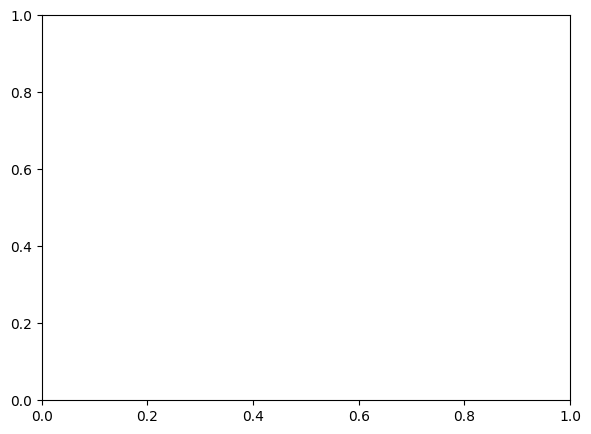

In [9]:

# Evaluar el modelo
print("\n📊 EVALUACIÓN FINAL:")
train_loss, train_acc = model.evaluate(train_generator, verbose=0)
val_loss, val_acc = model.evaluate(validation_generator, verbose=0)

print(f"Precisión en entrenamiento: {train_acc:.4f}")
print(f"Precisión en validación: {val_acc:.4f}")
print(f"Pérdida en entrenamiento: {train_loss:.4f}")
print(f"Pérdida en validación: {val_loss:.4f}")

# Gráficas de entrenamiento
plt.figure(figsize=(15, 5))

# Gráfica de precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación', linewidth=2)
plt.title('Precisión del Modelo', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación', linewidth=2)
plt.title('Pérdida del Modelo', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Guardar el modelo entrenado
model.save('modelo_clasificacion_residuos_final.h5')
print("✅ Modelo guardado como 'modelo_clasificacion_residuos_final.h5'")

# Guardar las clases para uso futuro
import json
with open('clases_modelo.json', 'w') as f:
    json.dump(train_generator.class_indices, f)
print("✅ Diccionario de clases guardado como 'clases_modelo.json'")

print("\n🎯 MODELO LISTO PARA USAR")
print(f"Clases: {list(train_generator.class_indices.keys())}")